Goal: Predict count(hourly rentals)
Primary metrics: RMSE, MAE, R2

# Bike Sharing Hourly Regression

**Goal:** predict `cnt` (hourly bike rentals) using the UCI / Kaggle Bike Sharing `hour.csv` dataset.  
**Primary metric:** RMSE on \(\log(1+\text{cnt})\) and RMSE on original scale for business interpretation.

**Notebook outline**
1. Setup and data load
2. Quick EDA
3. Feature engineering
4. Time-based splits and baseline
5. Models: Ridge and LightGBM with time-aware tuning
6. Interpretability with SHAP
7. Save pipeline and minimal FastAPI example


## 1. Setup and data load


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import timedelta

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Adjust path if needed. Place 'hour.csv' in the working directory.
DATA_PATH = "hour.csv"
assert os.path.exists(DATA_PATH), "Put 'hour.csv' in the notebook working directory."

df = pd.read_csv(DATA_PATH, parse_dates=['dteday'])
df.shape

(17379, 17)

In [7]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## 2. Quick EDA
- Check missing values, types, and target distribution.
- Visualize hourly and weekly patterns.


In [8]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


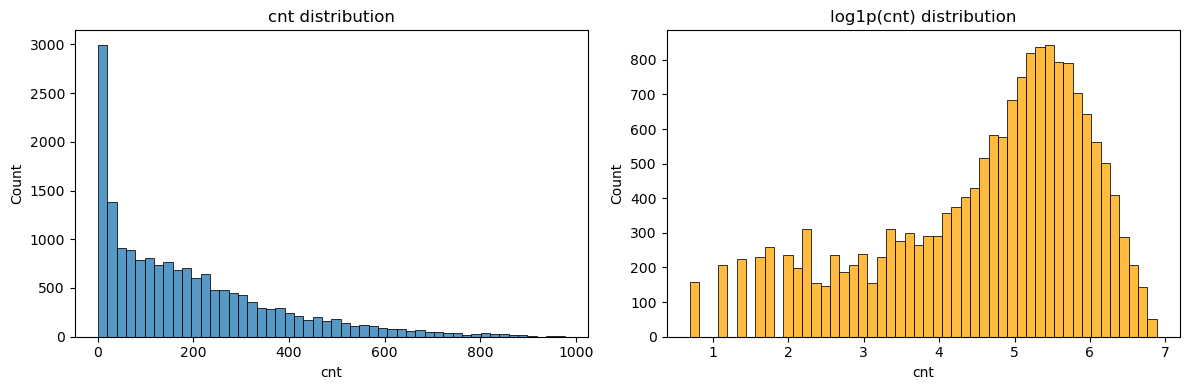

In [9]:
# target distribution
import matplotlib.ticker as mtick
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df['cnt'], bins=50, kde=False)
plt.title('cnt distribution')
plt.subplot(1,2,2)
sns.histplot(np.log1p(df['cnt']), bins=50, kde=False, color='orange')
plt.title('log1p(cnt) distribution')
plt.tight_layout()

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


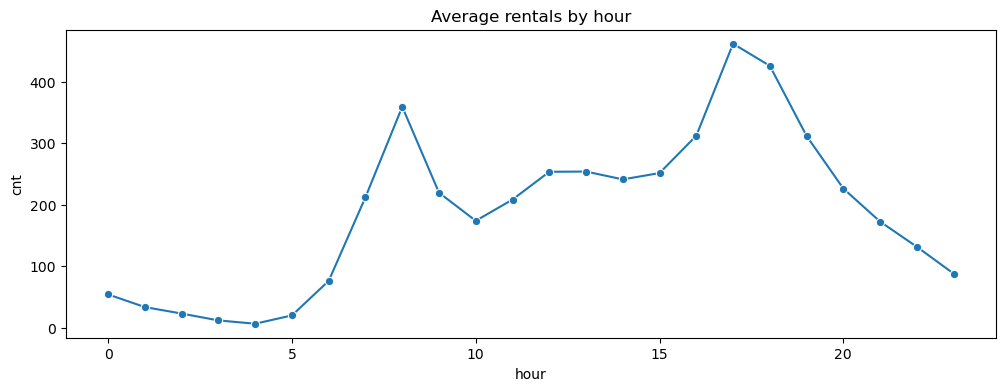

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


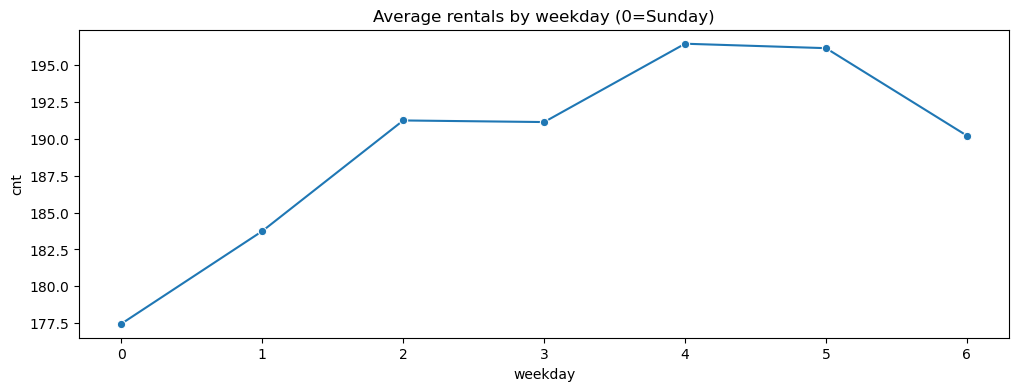

In [10]:
# time patterns
df['hour'] = df['hr']
df['weekday'] = df['weekday']  # 0: Sunday ... 6: Saturday in dataset
df['date'] = df['dteday']

plt.figure(figsize=(12,4))
sns.lineplot(data=df.groupby('hour')['cnt'].mean().reset_index(), x='hour', y='cnt', marker='o')
plt.title('Average rentals by hour')
plt.show()

plt.figure(figsize=(12,4))
sns.lineplot(data=df.groupby('weekday')['cnt'].mean().reset_index(), x='weekday', y='cnt', marker='o')
plt.title('Average rentals by weekday (0=Sunday)')
plt.show()


## 3. Feature engineering
- Create datetime features, categorical encodings, lag features (1, 24, 168), rolling means.
- Transform target: `y = log1p(cnt)`.

In [12]:
df = df.sort_values(['dteday', 'hr']).reset_index(drop=True)

# Target transform
df['y'] = np.log1p(df['cnt'])

# Datetime features
df['datetime'] = pd.to_datetime(df['dteday']) + pd.to_timedelta(df['hr'], unit='h')
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek
df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)
df['is_working_hour'] = df['hour'].isin([7,8,9,16,17,18]).astype(int)  # commute hours

# Keep original weather features: temp, atemp, hum, windspeed
# Categorical: season, weathersit, holiday, workingday
cat_cols = ['season', 'weathersit', 'holiday', 'workingday']

# Lag features (careful with leakage)
for lag in [1, 24, 168]:
    df[f'lag_{lag}'] = df['y'].shift(lag)

# Rolling means on log-target
df['roll_3'] = df['y'].shift(1).rolling(window=3, min_periods=1).mean()
df['roll_24'] = df['y'].shift(1).rolling(window=24, min_periods=1).mean()

# Drop rows with NaNs introduced by lags
df = df.dropna(subset=['lag_1', 'lag_24', 'lag_168']).reset_index(drop=True)
df.shape

(17211, 32)

In [13]:
df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,month,day,dayofweek,is_weekend,is_working_hour,lag_1,lag_24,lag_168,roll_3,roll_24
0,169,2011-01-08,1,0,1,7,0,6,0,2,...,1,8,5,1,1,1.098612,4.442651,2.833213,1.194506,3.642016
1,170,2011-01-08,1,0,1,8,0,6,0,3,...,1,8,5,1,1,2.302585,5.351858,3.713572,1.730986,3.552847
2,171,2011-01-08,1,0,1,9,0,6,0,3,...,1,8,5,1,1,2.772589,4.905275,3.496508,2.057929,3.445377
3,172,2011-01-08,1,0,1,10,0,6,0,2,...,1,8,5,1,0,3.044522,4.158883,2.639057,2.706565,3.367846
4,173,2011-01-08,1,0,1,11,0,6,0,2,...,1,8,5,1,0,4.127134,4.219508,0.693147,3.314749,3.366523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17206,17375,2012-12-31,1,1,12,19,0,1,1,2,...,12,31,0,0,0,4.812184,4.634729,3.295837,5.096256,4.141734
17207,17376,2012-12-31,1,1,12,20,0,1,1,2,...,12,31,0,0,0,4.787492,4.290459,2.944439,4.901874,4.148099
17208,17377,2012-12-31,1,1,12,21,0,1,1,1,...,12,31,0,0,0,4.499810,3.871201,3.178054,4.699829,4.156822
17209,17378,2012-12-31,1,1,12,22,0,1,1,1,...,12,31,0,0,0,4.510860,3.610918,3.135494,4.599387,4.183474


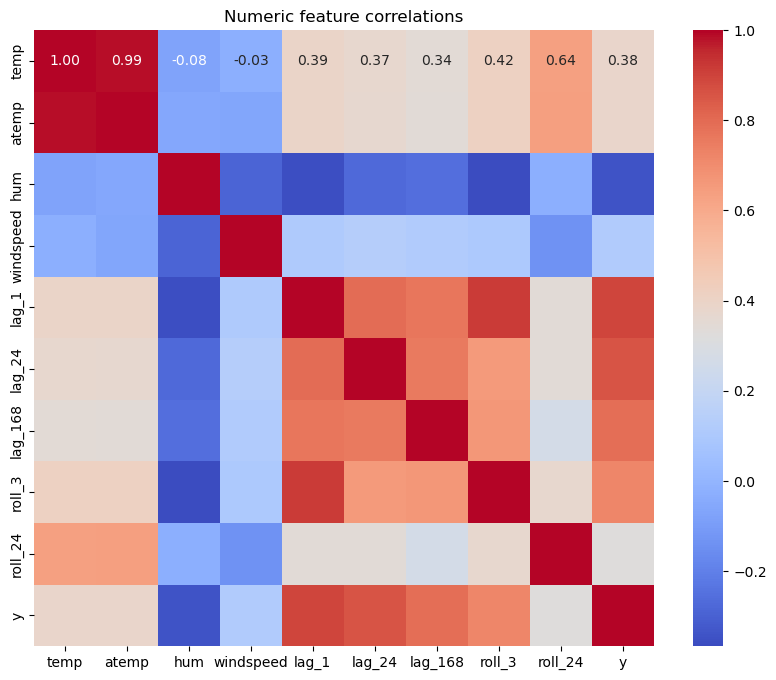

In [14]:
# quick feature correlation (numeric)
num_cols = ['temp','atemp','hum','windspeed','lag_1','lag_24','lag_168','roll_3','roll_24','y']
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Numeric feature correlations')
plt.show()

In [15]:
df[num_cols].corr()

,temp,atemp,hum,windspeed,lag_1,lag_24,lag_168,roll_3,roll_24,y
temp,1.000000,0.987544,-0.076216,-0.026113,0.394809,0.371285,0.344085,0.415415,0.636784,0.384518
atemp,0.987544,1.000000,-0.058507,-0.064791,0.392440,0.366976,0.338454,0.413274,0.642164,0.381659
hum,-0.076216,-0.058507,1.000000,-0.291633,-0.358015,-0.273944,-0.255480,-0.366362,-0.029702,-0.343858
windspeed,-0.026113,-0.064791,-0.291633,1.000000,0.113571,0.133700,0.114233,0.099950,-0.138754,0.114490
lag_1,0.394809,0.392440,-0.358015,0.113571,1.000000,0.793069,0.769811,0.916285,0.342259,0.895950
lag_24,0.371285,0.366976,-0.273944,0.133700,0.793069,1.000000,0.757294,0.657347,0.342762,0.856137
lag_168,0.344085,0.338454,-0.255480,0.114233,0.769811,0.757294,1.000000,0.664176,0.265070,0.790626
roll_3,0.415415,0.413274,-0.366362,0.099950,0.916285,0.657347,0.664176,1.000000,0.375042,0.719957
roll_24,0.636784,0.642164,-0.029702,-0.138754,0.342259,0.342762,0.265070,0.375042,1.000000,0.325180
y,0.384518,0.381659,-0.343858,0.114490,0.895950,0.856137,0.790626,0.719957,0.325180,1.000000


## 4. Time-based split and baseline
- Split by time: train (70%), val (15%), test (15%) — contiguous by datetime.
- Baseline: persistence model (predict previous hour), Linear/Ridge baseline.


In [16]:
# time-based split
df = df.sort_values('datetime').reset_index(drop=True)
n = len(df)
train_end = int(0.70 * n)
val_end = int(0.85 * n)

train = df.iloc[:train_end].copy()
val = df.iloc[train_end:val_end].copy()
test = df.iloc[val_end:].copy()

print("Sizes:", len(train), len(val), len(test))

Sizes: 12047 2582 2582


In [17]:
# baseline persistence (predict lag_1)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def eval_preds(y_true, y_pred, desc=""):
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{desc} RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

# Evaluate on validation (log scale)
eval_preds(val['y'], val['lag_1'], "Persistence (log) on val")

# Back-transform RMSE to original scale for business interpretation
def rmse_original_scale(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return mean_squared_error(y_true, y_pred, squared=False)

print("Persistence RMSE on original scale:", rmse_original_scale(val['y'], val['lag_1']))


Persistence (log) on val RMSE: 0.6344, MAE: 0.4755, R2: 0.7735
Persistence RMSE on original scale: 136.74820245725525


- The persistence model is strong (R2: 0.7735) explaining about 77% of variance
- High original-scale RMSE suggests large absolute variability in counts)

In [30]:
mean_cnt = df['cnt'].mean()
rmse_orig = 136.74820245725525
print("Mean cnt:", mean_cnt)
print("Relative RMSE:", rmse_orig / mean_cnt)

Mean cnt: 190.7613735401778
Relative RMSE: 0.7168547799770041


In [31]:
mae_orig = mean_absolute_error(np.expm1(y_val), np.expm1(val['lag_1']))
print("MAE original:", mae_orig)

MAE original: 93.22269558481797


<Axes: xlabel='hour'>

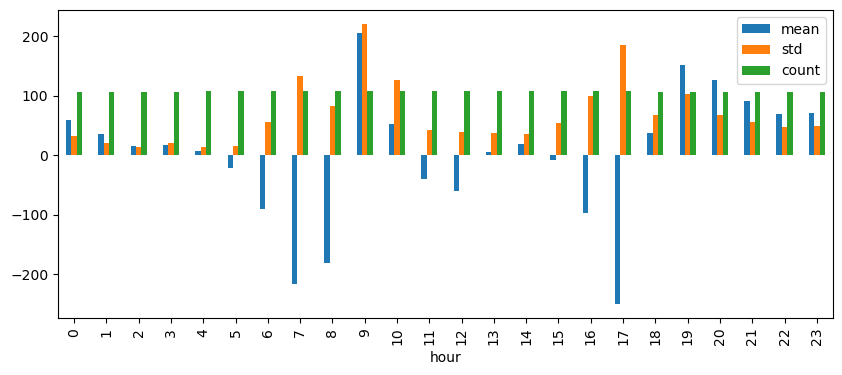

In [32]:
val['pred_log'] = val['lag_1']
val['pred'] = np.expm1(val['pred_log'])
val['error'] = val['pred'] - np.expm1(val['y'])
val.groupby('hour')['error'].agg(['mean','std','count']).plot(kind='bar', figsize=(10,4))


In [34]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

grp = val.copy()
grp['pred'] = np.expm1(grp['pred_log'])  # if you stored log preds
grp['actual'] = np.expm1(grp['y'])
hour_stats = grp.groupby('hour').apply(
    lambda g: pd.Series({
        'mean_resid': (g['pred'] - g['actual']).mean(),
        'mae': mean_absolute_error(g['actual'], g['pred']),
        'rmse': np.sqrt(((g['pred'] - g['actual'])**2).mean()),
        'std_resid': (g['pred'] - g['actual']).std(),
        'count': len(g)
    })
).reset_index()
hour_stats


C:\Users\Антон\AppData\Local\Temp\ipykernel_23432\2571527017.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hour_stats = grp.groupby('hour').apply(


,hour,mean_resid,mae,rmse,std_resid,count
0,0,58.915888,59.588785,67.259853,32.599665,107.0
1,1,35.252336,35.700935,40.856942,20.750582,107.0
2,2,15.831776,16.579439,20.735991,13.454666,107.0
3,3,17.074766,17.953271,26.706260,20.631402,107.0
4,4,6.740741,9.425926,14.901529,13.351727,108.0
5,5,-22.194444,23.898148,27.421099,16.178593,108.0
6,6,-89.731481,90.138889,105.311399,55.381870,108.0
7,7,-216.166667,216.166667,253.297220,132.643750,108.0
8,8,-180.555556,180.814815,198.240688,82.229373,108.0
9,9,205.638889,276.027778,300.771031,220.513269,108.0


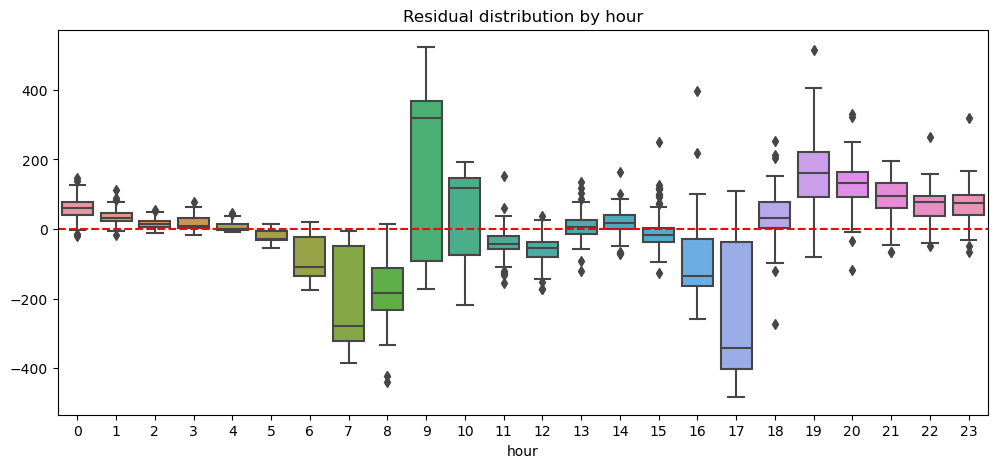

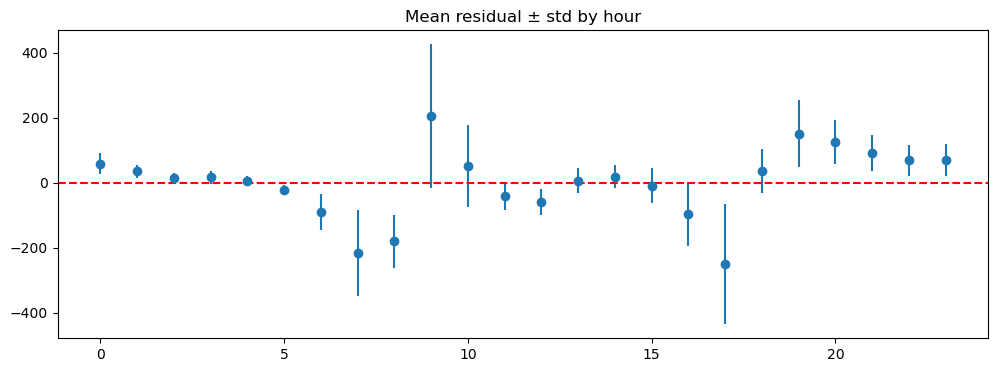

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot of residuals by hour
plt.figure(figsize=(12,5))
sns.boxplot(x='hour', y=(grp['pred']-grp['actual']), data=grp)
plt.title('Residual distribution by hour')
plt.axhline(0, color='red', linestyle='--')
plt.show()

# Mean residual with error bars
plt.figure(figsize=(12,4))
plt.errorbar(hour_stats['hour'], hour_stats['mean_resid'], yerr=hour_stats['std_resid'], fmt='o')
plt.axhline(0, color='red', linestyle='--')
plt.title('Mean residual ± std by hour')
plt.show()

In [18]:
# simple Ridge baseline with minimal preprocessing
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

feature_cols = ['hour','dayofweek','month','is_weekend','is_working_hour',
                'temp','atemp','hum','windspeed','lag_1','lag_24','lag_168','roll_3','roll_24',
                'season','weathersit','holiday','workingday']

num_features = ['hour','dayofweek','month','is_weekend','is_working_hour',
                'temp','atemp','hum','windspeed','lag_1','lag_24','lag_168','roll_3','roll_24']
cat_features = ['season','weathersit','holiday','workingday']

num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

ridge_pipe = Pipeline(steps=[
    ('pre', preprocessor),
    ('model', Ridge(random_state=RANDOM_STATE))
])

X_train = train[feature_cols]
y_train = train['y']
X_val = val[feature_cols]
y_val = val['y']

ridge_pipe.fit(X_train, y_train)
y_val_pred = ridge_pipe.predict(X_val)
eval_preds(y_val, y_val_pred, "Ridge on val (log)")
print("Ridge RMSE original scale:", rmse_original_scale(y_val, y_val_pred))


Ridge on val (log) RMSE: 0.3633, MAE: 0.2713, R2: 0.9257
Ridge RMSE original scale: 91.8497878854061


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


## 5. LightGBM model with time-aware tuning
- Use `TimeSeriesSplit` for cross-validation during hyperparameter search.
- Optimize RMSE on log-target.


In [20]:
# LightGBM training with TimeSeriesSplit
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

# Prepare data for LightGBM (we'll use preprocessor to transform features)
X = df[feature_cols]
y = df['y']

# Create transformed arrays for model training (fit preprocessor on train only)
preprocessor.fit(train[feature_cols])
X_train_trans = preprocessor.transform(train[feature_cols])
X_val_trans = preprocessor.transform(val[feature_cols])
X_test_trans = preprocessor.transform(test[feature_cols])

# LightGBM dataset
lgb_train = lgb.Dataset(X_train_trans, label=train['y'])
lgb_val = lgb.Dataset(X_val_trans, label=val['y'], reference=lgb_train)

# Basic parameters
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'seed': RANDOM_STATE
}

# Use callbacks for early stopping and logging
callbacks = [
    lgb.early_stopping(stopping_rounds=50),
    lgb.log_evaluation(period=100)
]

gbm = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_val],
    callbacks=callbacks
)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Training until validation scores don't improve for 50 rounds
[100]	training's rmse: 0.23473	valid_1's rmse: 0.261313
[200]	training's rmse: 0.203102	valid_1's rmse: 0.255003
[300]	training's rmse: 0.180112	valid_1's rmse: 0.254035
Early stopping, best iteration is:
[260]	training's rmse: 0.188873	valid_1's rmse: 0.253576


In [21]:
# Evaluate on validation
y_val_pred_gbm = gbm.predict(X_val_trans, num_iteration=gbm.best_iteration)
eval_preds(y_val, y_val_pred_gbm, "LightGBM on val (log)")
print("LightGBM RMSE original scale:", rmse_original_scale(y_val, y_val_pred_gbm))

LightGBM on val (log) RMSE: 0.2536, MAE: 0.1846, R2: 0.9638
LightGBM RMSE original scale: 65.49588082504313


In [22]:
# TimeSeriesSplit + RandomizedSearchCV (optional, can be long)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import make_scorer

# Wrap LightGBM in sklearn API for CV
from lightgbm import LGBMRegressor
lgbm_sklearn = LGBMRegressor(random_state=RANDOM_STATE, objective='regression', n_jobs=-1)

param_dist = {
    'n_estimators': [200, 500, 800],
    'num_leaves': [31, 50, 80],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_samples': [5, 10, 20],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

tscv = TimeSeriesSplit(n_splits=4)
def rmse_scorer(y_true, y_pred):
    return -mean_squared_error(y_true, y_pred, squared=False)  # negative for sklearn

from sklearn.model_selection import RandomizedSearchCV
pipe_lgb = Pipeline(steps=[('pre', preprocessor), ('model', lgbm_sklearn)])
rs = RandomizedSearchCV(pipe_lgb, {'model__' + k: v for k,v in param_dist.items()},
                        n_iter=20, cv=tscv, scoring=make_scorer(mean_squared_error, greater_is_better=False, squared=False),
                        verbose=2, random_state=RANDOM_STATE, n_jobs=2)

# Fit on train+val to find best hyperparams (time-consuming). We will fit on train only to keep validation separate.
rs.fit(train[feature_cols], train['y'])
print("Best params:", rs.best_params_)


Fitting 4 folds for each of 20 candidates, totalling 80 fits


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001088 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1573
[LightGBM] [Info] Number of data points in the train set: 12047, number of used features: 25
[LightGBM] [Info] Start training from score 4.432005
Best params: {'model__subsample': 0.6, 'model__num_leaves': 31, 'model__n_estimators': 800, 'model__min_child_samples': 20, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.6}


In [23]:
# Evaluate best estimator on validation and test
best_pipe = rs.best_estimator_
y_val_pred_best = best_pipe.predict(val[feature_cols])
eval_preds(y_val, y_val_pred_best, "Best LGBM (log) on val")
print("Best LGBM RMSE original scale:", rmse_original_scale(y_val, y_val_pred_best))

# Final evaluation on test
y_test_pred = best_pipe.predict(test[feature_cols])
eval_preds(test['y'], y_test_pred, "Best LGBM (log) on test")
print("Best LGBM RMSE original scale (test):", rmse_original_scale(test['y'], y_test_pred))


Best LGBM (log) on val RMSE: 0.2532, MAE: 0.1868, R2: 0.9639
Best LGBM RMSE original scale: 68.2683605246029
Best LGBM (log) on test RMSE: 0.2824, MAE: 0.2067, R2: 0.9602
Best LGBM RMSE original scale (test): 63.434803336698415


## 6. Interpretability with SHAP
- Use SHAP to explain global and local effects.


100%|===================| 1990/2000 [01:08<00:00]        

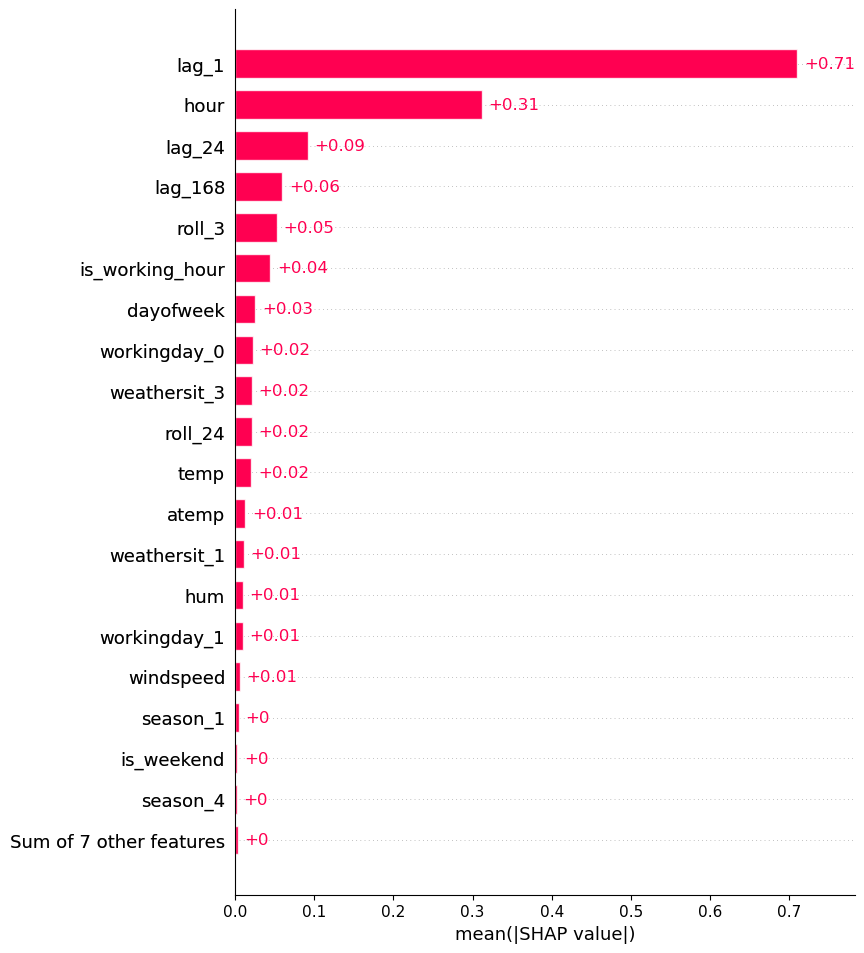

In [24]:
# Cell 15 — SHAP explanations
import shap

# Use a small sample for SHAP to speed up
X_sample = preprocessor.transform(df[feature_cols].iloc[-2000:])
model_for_shap = best_pipe.named_steps['model']

explainer = shap.Explainer(model_for_shap, X_sample, feature_names=(preprocessor.transformers_[0][2] + list(best_pipe.named_steps['pre'].transformers_[1][1].named_steps['ohe'].get_feature_names_out(cat_features))))
# Note: building feature names from ColumnTransformer can be verbose; below we create a helper to get names.

# Helper to get feature names after ColumnTransformer
def get_feature_names(column_transformer):
    feature_names = []
    for name, trans, cols in column_transformer.transformers_:
        if name == 'num':
            feature_names.extend(cols)
        elif name == 'cat':
            # get categories from OneHotEncoder
            ohe = trans.named_steps['ohe']
            ohe_names = list(ohe.get_feature_names_out(cols))
            feature_names.extend(ohe_names)
    return feature_names

feature_names = get_feature_names(preprocessor)
X_shap = preprocessor.transform(df[feature_cols].iloc[-2000:])
explainer = shap.Explainer(model_for_shap, X_shap, feature_names=feature_names)

shap_values = explainer(X_shap)

# Global importance
shap.plots.bar(shap_values, max_display=20)


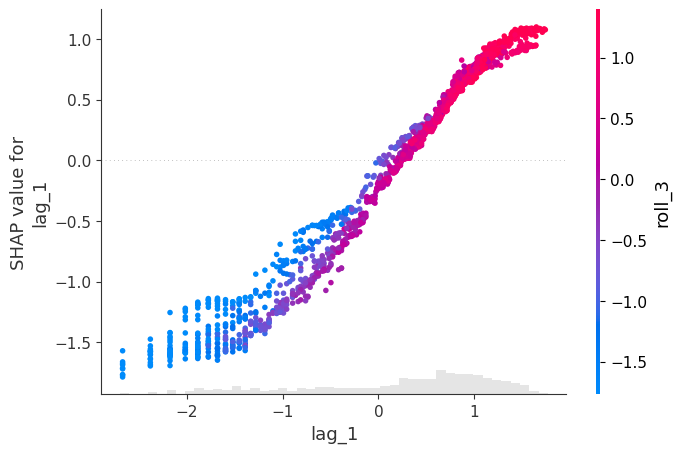

In [25]:
# SHAP dependence plot for top feature (example)
top_feat = feature_names[np.argsort(np.abs(shap_values.values).mean(0))[-1]]
shap.plots.scatter(shap_values[:, top_feat], color=shap_values)


## 7. Save pipeline for minimal FastAPI example
- Save the preprocessing + model pipeline with `joblib`.
- Provide a minimal FastAPI app that loads the pipeline and serves predictions.


In [27]:
# Save pipeline
import joblib
final_pipeline = best_pipe  # already includes preprocessor + model
joblib.dump(final_pipeline, "bike_sharing_pipeline.joblib")
print("Saved pipeline to bike_sharing_pipeline.joblib")


Saved pipeline to bike_sharing_pipeline.joblib
